In [ ]:
import pandas as pd
import datasets
from datasets import Image as Image_ds # change name because of similar PIL module
from datasets import Dataset
import os
import requests 
from PIL import Image
from tqdm import tqdm
import torch
from datasets import load_dataset
import numpy as np
import mteb

/work/code/art-multimodal-benchmark/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-09-08 11:21:41.923792: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [1]:
import numpy as np

In [1]:
import pandas as pd

In [2]:
import datasets
print(datasets.__version__)

/Users/au672746/Library/CloudStorage/OneDrive-Aarhusuniversitet/CHC/art-multimodal-benchmark/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3.6.0


In [3]:
#import datasets
#from datasets import Dataset
#from datasets import load_dataset
ds = datasets.load_from_disk('data/wikiart')
print(len(ds))

81444


In [4]:
torch_ds = ds.with_format('torch')

In [7]:
type(ds)

datasets.arrow_dataset.Dataset

In [18]:
import datasets

In [20]:
#import torch

ds = datasets.load_from_disk('data/wikiart')
#torch_ds = ds.with_format('torch')
#dataloader = torch.utils.data.DataLoader(torch_ds, batch_size=32, shuffle=False)
subset = ds.select(range(30))

In [22]:
subset.features

{'image': Image(mode=None, decode=True, id=None),
 'artist': ClassLabel(names=['Unknown Artist', 'boris-kustodiev', 'camille-pissarro', 'childe-hassam', 'claude-monet', 'edgar-degas', 'eugene-boudin', 'gustave-dore', 'ilya-repin', 'ivan-aivazovsky', 'ivan-shishkin', 'john-singer-sargent', 'marc-chagall', 'martiros-saryan', 'nicholas-roerich', 'pablo-picasso', 'paul-cezanne', 'pierre-auguste-renoir', 'pyotr-konchalovsky', 'raphael-kirchner', 'rembrandt', 'salvador-dali', 'vincent-van-gogh', 'hieronymus-bosch', 'leonardo-da-vinci', 'albrecht-durer', 'edouard-cortes', 'sam-francis', 'juan-gris', 'lucas-cranach-the-elder', 'paul-gauguin', 'konstantin-makovsky', 'egon-schiele', 'thomas-eakins', 'gustave-moreau', 'francisco-goya', 'edvard-munch', 'henri-matisse', 'fra-angelico', 'maxime-maufra', 'jan-matejko', 'mstislav-dobuzhinsky', 'alfred-sisley', 'mary-cassatt', 'gustave-loiseau', 'fernando-botero', 'zinaida-serebriakova', 'georges-seurat', 'isaac-levitan', 'joaquã\xadn-sorolla', 'jacek-

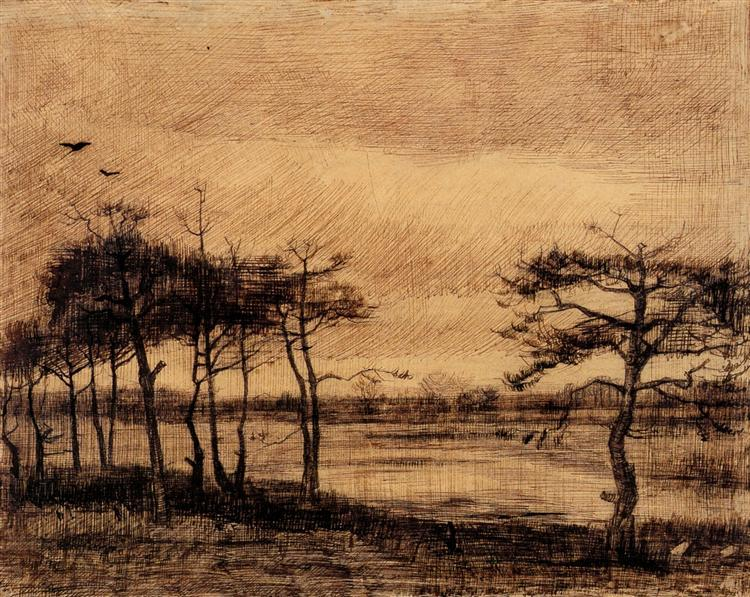

In [23]:
subset[0]['image']

In [3]:
from torch.utils.data import Dataset, DataLoader

class ImageDataset(Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]['image']

In [1]:
# load dataset from HuggingFace
import torch
from datasets import load_dataset
ds = load_dataset("louisebrix/smk_canon_paintings", split="train")
subset = ds.select(range(30))

/Users/au672746/Library/CloudStorage/OneDrive-Aarhusuniversitet/CHC/art-multimodal-benchmark/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
from torchvision import transforms
from torch.utils.data import DataLoader


transform = transforms.Compose([
    lambda x: x["image"].convert("pil"),  # convert HF image to PIL Image
    transforms.ToTensor(),
])

# 3. Use with_transform to apply the transform lazily on-the-fly (does NOT load all images at once)
dataset = subset.with_transform(lambda x: {"image": transform(x)})

# 4. Create DataLoader (this yields batches of tensors, no memory spike)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

In [4]:
torch_ds = ImageDataset(subset)
dataloader = DataLoader(
    torch_ds,
    batch_size=32,
    shuffle=False,            # ensures images stay in order
    #collate_fn=lambda x: x,   # keeps each batch as a list of PIL images
    num_workers=4             # parallel loading
)

In [5]:
import mteb

In [6]:
meta = mteb.get_model_meta('laion/CLIP-ViT-bigG-14-laion2B-39B-b160k')
model = meta.load_model()

In [25]:
def extract_embeddings(image_dataloader, model):
    
    #meta = mteb.get_model_meta(model_path)
    
    #print('loading model....')
    #model = meta.load_model()
    
    print('extracting embeddings...')
    embeddings = model.get_image_embeddings(image_dataloader)
    
    return embeddings

In [14]:
from torchvision import transforms

transform = transforms.ToTensor()

# If using Huggingface datasets, you can map the transform:
def transform_example(example):
    example['image'] = transform(example['image'])
    return example

dataset = subset.map(transform_example)

# Then create the DataLoader as usual
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

Map:  87%|████████▋ | 26/30 [00:10<00:00, 119.03 examples/s]Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.11/3.11.13/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py", line 239, in _feed
    reader_close()
  File "/opt/homebrew/Cellar/python@3.11/3.11.13/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/opt/homebrew/Cellar/python@3.11/3.11.13/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor
Map: 100%|██████████| 30/30 [00:32<00:00,  1.08s/ examples] 


In [16]:
dataset

Dataset({
    features: ['smk_id', 'period', 'start_year', 'title', 'first_artist', 'all_artists', 'num_artists', 'main_type', 'all_types', 'image_thumbnail', 'gender', 'birth_death', 'nationality', 'history', 'artist_roles', 'creator_roles', 'num_creators', 'techniques', 'enrichment_url', 'content_person', 'has_text', 'colors', 'geo_location', 'entropy', 'tags_en', 'image', 'rgb', 'embedding', 'grey_embedding', 'grey_image', 'exhibitions', 'acquisition_date', 'responsible_department', 'documentation', 'on_display', 'current_location_name', 'literary_reference', 'object_history_note', 'exhibition_venues', 'smk_exhibitions', 'ex_years', 'exb_canon', 'prod_diff', 'prod_notes', 'prod_year'],
    num_rows: 30
})

In [45]:
import numpy as np

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    lambda img: img.convert("RGB"),        # Convert HuggingFace Image to PIL
    lambda img: np.array(img),
    #transforms.Resize((224, 224)),         # Resize to fixed size (important!)
    #transforms.PILToTensor(),                 # Convert to tensor [3, H, W]
])

from torch.utils.data import Dataset

class HFImageDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.dataset[idx]["image"]  # HuggingFace Image object
        if self.transform:
            image = self.transform(image)   # Apply PIL conversion + resize + tensor
        return image  # No label

from torch.utils.data import DataLoader

dataset = HFImageDataset(hf_dataset=subset, transform=transform)

def pil_collate_fn(batch):
    # batch is a list of PIL Images, just return it as list without stacking
    return batch

dataloader = DataLoader(dataset, batch_size=32, shuffle=False, collate_fn=pil_collate_fn)

embeddings = model.get_image_embeddings(dataloader)

100%|██████████| 1/1 [00:51<00:00, 51.68s/it]


In [52]:
import multiprocessing

num_cores = multiprocessing.cpu_count()

In [51]:
from torchvision import transforms

transform = transforms.Compose([
    lambda img: img.convert("RGB"),        # Convert HuggingFace Image to PIL
    #lambda img: np.array(img),
    #transforms.Resize((224, 224)),         # Resize to fixed size (important!)
    transforms.PILToTensor(),                 # Convert to tensor [3, H, W]
])

from torch.utils.data import Dataset

class HFImageDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.dataset[idx]["image"]  # HuggingFace Image object
        if self.transform:
            image = self.transform(image)   # Apply PIL conversion + resize + tensor
        return image  # No label

from torch.utils.data import DataLoader

dataset = HFImageDataset(hf_dataset=subset, transform=transform)

dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

embeddings = model.get_image_embeddings(dataloader)

  0%|          | 0/1 [00:00<?, ?it/s]


RuntimeError: stack expects each tensor to be equal size, but got [3, 597, 750] at entry 0 and [3, 1659, 1382] at entry 1

In [49]:
embeddings.shape

torch.Size([30, 1280])

In [31]:
transform = transforms.Compose([
    transforms.ToTensor()                        # convert to tensor
])

In [33]:
dataset = HuggingfaceImageDataset(subset, image_transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

In [34]:
embeddings = extract_embeddings(dataloader, model)

/Users/au672746/Library/CloudStorage/OneDrive-Aarhusuniversitet/CHC/art-multimodal-benchmark/env/lib/python3.11/site-packages/mteb/models/openclip_models.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
/Users/au672746/Library/CloudStorage/OneDrive-Aarhusuniversitet/CHC/art-multimodal-benchmark/env/lib/python3.11/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


extracting embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]


RuntimeError: stack expects each tensor to be equal size, but got [3, 597, 750] at entry 0 and [3, 1659, 1382] at entry 1

In [26]:
embeddings = extract_embeddings(dataloader, model)

/Users/au672746/Library/CloudStorage/OneDrive-Aarhusuniversitet/CHC/art-multimodal-benchmark/env/lib/python3.11/site-packages/mteb/models/openclip_models.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
/Users/au672746/Library/CloudStorage/OneDrive-Aarhusuniversitet/CHC/art-multimodal-benchmark/env/lib/python3.11/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


extracting embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]


AttributeError: 'list' object has no attribute 'convert'

In [3]:
from functools import partial

In [6]:
# load dataset from the hub
hf_data = datasets.load_dataset('huggan/wikiart', split='train', streaming=True)
wiki_subset = hf_data.take(200)

# convert dataset to iterable generator
def gen_from_iterable_dataset(iterable_ds):
    yield from iterable_ds

# convert to dataset to be saved locally
ds = datasets.Dataset.from_generator(partial(gen_from_iterable_dataset, wiki_subset), features=wiki_subset.features)

Generating train split: 200 examples [00:19, 10.38 examples/s]


In [7]:
ds.save_to_disk(os.path.join('data', f"wiki_subset"))

Saving the dataset (1/1 shards): 100%|██████████| 200/200 [00:00<00:00, 3749.47 examples/s]


In [3]:
import os
leaderboard = pd.read_csv(os.path.join('data', 'mieb_leaderboard.csv'))

In [4]:
leaderboard

,Unnamed: 0,Rank (Borda),Model,Zero-shot,Memory Usage (MB),Number of Parameters,Embedding Dimensions,Max Tokens,Mean (Task),Mean (TaskType),Any Any Retrieval,Image Classification,Image Clustering,Visual ST eng,Visual ST multi
0,0,1,[EVA02-CLIP-bigE-14-plus](https://huggingface....,100%,19073,5B,1024,77,77.51,70.23,68.30,85.95,92.38,70.49,34.04
1,1,2,[CLIP-ViT-bigG-14-laion2B-39B-b160k](https://h...,100%,9689,2B,1280,77,75.42,69.07,66.57,83.64,85.59,70.01,39.52
2,2,3,[EVA02-CLIP-bigE-14](https://huggingface.co/Qu...,100%,17929,4B,1024,77,75.95,68.50,67.32,84.51,89.42,67.56,33.71
3,3,4,[siglip-so400m-patch14-384](https://huggingfac...,100%,3349,878M,1152,64,75.60,69.32,67.08,84.58,82.11,67.02,45.82
4,4,5,[siglip-large-patch16-384](https://huggingface...,100%,2489,652M,1024,64,74.97,68.64,66.86,83.70,79.94,68.08,44.62
5,5,6,[CLIP-ViT-g-14-laion2B-s34B-b88K](https://hugg...,100%,5215,1B,1024,77,74.00,67.05,65.23,82.77,82.74,68.00,36.54
6,6,7,[siglip-large-patch16-256](https://huggingface...,100%,2488,652M,1024,64,73.91,67.76,65.40,82.46,82.13,66.06,42.76
7,7,8,[CLIP-ViT-L-14-DataComp.XL-s13B-b90K](https://...,100%,1633,428M,768,77,74.27,68.66,65.18,81.96,86.44,69.02,40.69
8,8,9,[CLIP-ViT-H-14-laion2B-s32B-b79K](https://hugg...,100%,3762,986M,1024,77,73.64,66.89,64.98,82.48,83.86,64.57,38.55
9,9,10,[siglip-base-patch16-512](https://huggingface....,100%,777,204M,768,64,72.57,66.10,65.70,80.89,74.65,66.31,42.97


In [6]:
leaderboard_new = leaderboard[~leaderboard['Model'].str.contains('EVA', case=False, na=False)]

In [8]:
leaderboard_new.reset_index(drop=True, inplace=True)

In [10]:
leaderboard_new.to_csv(os.path.join('data', 'mieb_leaderboard_no_EVA.csv'))

In [12]:
ds[1:20]['period']

['1870',
 '1800',
 '1800',
 '1844',
 '1750',
 '1834',
 '1865',
 '1846',
 '1753',
 '1753',
 '1838',
 '1826',
 '1798-1801',
 '1847',
 '1820-1834',
 '1841-1843',
 '1844',
 '1843',
 '1837']

In [10]:
ds.features.keys()

dict_keys(['smk_id', 'period', 'start_year', 'title', 'first_artist', 'all_artists', 'num_artists', 'main_type', 'all_types', 'image_thumbnail', 'gender', 'birth_death', 'nationality', 'history', 'artist_roles', 'creator_roles', 'num_creators', 'techniques', 'enrichment_url', 'content_person', 'has_text', 'colors', 'geo_location', 'entropy', 'tags_en', 'image', 'rgb', 'embedding', 'grey_embedding', 'grey_image', 'exhibitions', 'acquisition_date', 'responsible_department', 'documentation', 'on_display', 'current_location_name', 'literary_reference', 'object_history_note', 'exhibition_venues', 'smk_exhibitions', 'ex_years', 'exb_canon', 'prod_diff', 'prod_notes', 'prod_year'])

In [10]:
leaderboard['Model'].iloc[10]

'[CLIP-ViT-L-14-laion2B-s32B-b82K](https://huggingface.co/laion/CLIP-ViT-L-14-laion2B-s32B-b82K)'

In [4]:
# get list of all model metas
metas = mteb.get_model_metas()

# filter out image models, save their names
vision_names = [meta.name for meta in metas if "image" in meta.modalities]

To match the model metas with leaderboard positions, we need to find the full model paths of the leaderboard models:

In [6]:
# get model names from column of names + HF links
leaderboard_model_names = []

for model_link in leaderboard['Model'].iloc[0:20]:
    model_name = model_link.split(']')[0][1:]
    leaderboard_model_names.append(model_name)

# match model name to full HF path
models_full_paths = []

for model in leaderboard_model_names:
    for path in vision_names:
        if path.endswith(model):
            models_full_paths.append(path)

model_metas = []
for model in models_full_paths:
    model_meta = mteb.get_model_meta(model)
    model_metas.append(dict(model_meta))

model_metadata = pd.DataFrame(model_metas)

In [7]:
model_metadata.head()

,name,revision,release_date,languages,loader,n_parameters,memory_usage_mb,max_tokens,embed_dim,license,...,public_training_data,framework,reference,similarity_fn_name,use_instructions,training_datasets,adapted_from,superseded_by,is_cross_encoder,modalities
0,QuanSun/EVA02-CLIP-bigE-14-plus,11afd202f2ae80869d6cef18b1ec775e79bd8d12,2023-04-26,[eng-Latn],functools.partial(<function evaclip_loader at ...,5000000000,19073.0,77.0,1024,mit,...,https://laion.ai/blog/laion-5b/,[PyTorch],https://huggingface.co/QuanSun/EVA-CLIP,None,False,{},None,None,None,"[image, text]"
1,laion/CLIP-ViT-bigG-14-laion2B-39B-b160k,bc7788f151930d91b58474715fdce5524ad9a189,2023-01-23,[eng-Latn],functools.partial(<function openclip_loader at...,2540000000,9689.0,77.0,1280,mit,...,https://laion.ai/blog/laion-5b/,[PyTorch],https://huggingface.co/laion/CLIP-ViT-bigG-14-...,None,False,{},None,None,None,"[image, text]"
2,QuanSun/EVA02-CLIP-bigE-14,11afd202f2ae80869d6cef18b1ec775e79bd8d12,2023-04-26,[eng-Latn],functools.partial(<function evaclip_loader at ...,4700000000,17929.0,77.0,1024,mit,...,https://laion.ai/blog/laion-5b/,[PyTorch],https://huggingface.co/QuanSun/EVA-CLIP,None,False,{},None,None,None,"[image, text]"
3,google/siglip-so400m-patch14-384,9fdffc58afc957d1a03a25b10dba0329ab15c2a3,2024-01-08,[eng-Latn],functools.partial(<class 'mteb.models.siglip_m...,878000000,3349.0,64.0,1152,apache-2.0,...,None,[PyTorch],https://huggingface.co/google/siglip-so400m-pa...,None,False,{},None,None,None,"[image, text]"
4,google/siglip-large-patch16-384,ce005573a40965dfd21fd937fbdeeebf2439fc35,2024-01-08,[eng-Latn],functools.partial(<class 'mteb.models.siglip_m...,652000000,2489.0,64.0,1024,apache-2.0,...,None,[PyTorch],https://huggingface.co/google/siglip-large-pat...,None,False,{},None,None,None,"[image, text]"


In [14]:
model_metadata.to_csv('testy.csv')

In [8]:
small_subset = ds.select(range(6))

In [9]:
def extract_embeddings(images, model_path):
    
    meta = mteb.get_model_meta(model_path)
    
    model = meta.load_model()
    
    embeddings = model.get_image_embeddings(images)
    
    return embeddings

In [10]:
from open_clip import create_model_and_transforms

In [11]:
# test every model on 1 image to get not-installed dependecies..
for model_path in model_metadata['name']:
    try:
        embedding = extract_embeddings(small_subset[0]['image'], model_path)
        print(f"{model_path}: {embedding.shape}")
    except Exception as e:
        print(f'could not load model {model_path}: {e}')

could not load model QuanSun/EVA02-CLIP-bigE-14-plus: Please run `git clone git@github.com:baaivision/EVA.git`,`pip install ninja timm``pip install -v -U git+https://github.com/facebookresearch/xformers.git@main#egg=xformers``git clone https://github.com/NVIDIA/apex && cd apex && pip install -v --disable-pip-version-check --no-build-isolation --no-cache-dir ./`


KeyboardInterrupt: 

In [5]:
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np

In [7]:
table = pa.Table.from_pydict({'embedding': ds['embedding']})

In [9]:
pq.write_table(table, 'tester')

In [ ]:
import torch
from torch import nn 

# make sure code can run on both GPU and CPU

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
def fit_and_predict(train_data, 
                    val_data, 
                    test_data, 
                    hidden_layer_size, 
                    embedding_col,
                    label_col, # label
                    batch_size,
                    epochs):

    # use GPU if available, otherwise CPU
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Code is running on {device}")

    # handle this differently ????? 
    num_classes = train_data.features[label_col].num_classes

    # make sure tensor will give the correct output with this
    input_size = len(train_data[0][embedding_col])

    # build torch neural network and send to available device (either CPU (default) or GPU if available)
    model = build_classification_model(input_size, hidden_layer_size, num_classes).to(device)

In [25]:
embeddings_test = extract_embeddings(small_subset['image'], 'openai/clip-vit-base-patch32')

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
100%|██████████| 1/1 [00:00<00:00,  4.40it/s]


In [26]:
embeddings_test.shape

torch.Size([6, 512])

In [30]:
embeddings_np = embeddings_test.cpu().numpy()

embeddings_list = [emb for emb in embeddings_np]  # list of 1D numpy arrays, length=number of rows

small_subset = small_subset.add_column('testy', embeddings_list)

In [33]:
type(small_subset[0]['testy'])

list

In [88]:
model_meta = pd.DataFrame([dict(mteb.get_model_meta(models_full_paths[0]))])
#testy = pd.DataFrame([model_meta])

In [89]:
model_meta

,name,revision,release_date,languages,loader,n_parameters,memory_usage_mb,max_tokens,embed_dim,license,...,public_training_data,framework,reference,similarity_fn_name,use_instructions,training_datasets,adapted_from,superseded_by,is_cross_encoder,modalities
0,QuanSun/EVA02-CLIP-bigE-14-plus,11afd202f2ae80869d6cef18b1ec775e79bd8d12,2023-04-26,[eng-Latn],functools.partial(<function evaclip_loader at ...,5000000000,19073.0,77.0,1024,mit,...,https://laion.ai/blog/laion-5b/,[PyTorch],https://huggingface.co/QuanSun/EVA-CLIP,None,False,{},None,None,None,"[image, text]"


In [85]:
testy.columns

Index(['name', 'revision', 'release_date', 'languages', 'loader',
       'n_parameters', 'memory_usage_mb', 'max_tokens', 'embed_dim', 'license',
       'open_weights', 'public_training_code', 'public_training_data',
       'framework', 'reference', 'similarity_fn_name', 'use_instructions',
       'training_datasets', 'adapted_from', 'superseded_by',
       'is_cross_encoder', 'modalities'],
      dtype='object')

In [86]:
testy

,name,revision,release_date,languages,loader,n_parameters,memory_usage_mb,max_tokens,embed_dim,license,...,public_training_data,framework,reference,similarity_fn_name,use_instructions,training_datasets,adapted_from,superseded_by,is_cross_encoder,modalities
0,QuanSun/EVA02-CLIP-bigE-14-plus,11afd202f2ae80869d6cef18b1ec775e79bd8d12,2023-04-26,[eng-Latn],functools.partial(<function evaclip_loader at ...,5000000000,19073.0,77.0,1024,mit,...,https://laion.ai/blog/laion-5b/,[PyTorch],https://huggingface.co/QuanSun/EVA-CLIP,None,False,{},None,None,None,"[image, text]"


In [81]:
mteb.get_model_metas(models_full_paths)

[ModelMeta(name='openai/clip-vit-large-patch14', revision='32bd64288804d66eefd0ccbe215aa642df71cc41', release_date='2021-02-26', languages=['eng-Latn'], loader=functools.partial(<class 'mteb.models.clip_models.CLIPModelWrapper'>, model_name='openai/clip-vit-large-patch14'), n_parameters=428000000, memory_usage_mb=1631.0, max_tokens=77.0, embed_dim=768, license=None, open_weights=True, public_training_code=None, public_training_data=None, framework=['PyTorch'], reference='https://huggingface.co/openai/clip-vit-large-patch14', similarity_fn_name=None, use_instructions=False, training_datasets=None, adapted_from=None, superseded_by=None, is_cross_encoder=None, modalities=['image', 'text']),
 ModelMeta(name='facebook/dinov2-large', revision='47b73eefe95e8d44ec3623f8890bd894b6ea2d6c', release_date='2023-07-18', languages=['eng-Latn'], loader=functools.partial(<class 'mteb.models.dino_models.DINOModelWrapper'>, model_name='facebook/dinov2-large'), n_parameters=304000000, memory_usage_mb=1161

In [10]:
import timm

In [11]:
timm.list_models('*eva*')

['eva02_base_patch14_224',
 'eva02_base_patch14_448',
 'eva02_base_patch16_clip_224',
 'eva02_enormous_patch14_clip_224',
 'eva02_large_patch14_224',
 'eva02_large_patch14_448',
 'eva02_large_patch14_clip_224',
 'eva02_large_patch14_clip_336',
 'eva02_small_patch14_224',
 'eva02_small_patch14_336',
 'eva02_tiny_patch14_224',
 'eva02_tiny_patch14_336',
 'eva_giant_patch14_224',
 'eva_giant_patch14_336',
 'eva_giant_patch14_560',
 'eva_giant_patch14_clip_224',
 'eva_large_patch14_196',
 'eva_large_patch14_336']